# A scalar autograd engine

PyTorch can compute derivatives of a tensor expression automatically, but the mechanism is easier to inspect in a small scalar example. This notebook builds that mechanism from the bottom up. A `Value` stores a number, the derivative of a final output with respect to that number, and the local operation that produced it. The objects form a directed acyclic computation graph.

The implementation is intentionally small. It is not a replacement for PyTorch: it has no tensor operations, broadcasting, devices, batching, or optimized kernels. Its purpose is to make reverse-mode automatic differentiation explicit before using the library implementation in the MLP notebook that follows.


## Local derivatives and a computation graph

For a scalar expression, each operation contributes a local derivative. If `z = x * y`, then `dz/dx = y` and `dz/dy = x`. If `z = tanh(x)`, then `dz/dx = 1 - tanh(x)^2`. The chain rule combines these local derivatives along every path from an input to the output.

The graph stores only the immediate parents of each value. The backward pass later visits the graph in reverse topological order, so a node has received all contributions from its children before its own parents are updated.


In [1]:
import math
from collections import deque


class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = float(data)
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):
        return other + (-self)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __pow__(self, exponent):
        out = Value(self.data ** exponent, (self,), f'**{exponent}')

        def _backward():
            self.grad += exponent * self.data ** (exponent - 1) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        t = math.tanh(self.data)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t ** 2) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        order, visited = [], set()

        def build(node):
            if node not in visited:
                visited.add(node)
                for parent in node._prev:
                    build(parent)
                order.append(node)

        build(self)
        self.grad = 1.0
        for node in reversed(order):
            node._backward()


## Visualizing the computation graph

The graph below uses the same node-and-operation view as Karpathy's micrograd notebook. Each rounded node is a `Value` with its data and accumulated gradient; the square nodes are operations. Arrows point from inputs to the operation that combines them and then to the resulting value.


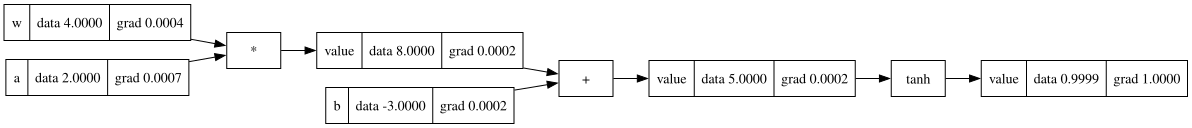

In [2]:
from IPython.display import SVG, display
import subprocess


def trace(root):
    nodes, edges = set(), set()

    def build(value):
        if value not in nodes:
            nodes.add(value)
            for parent in value._prev:
                edges.add((parent, value))
                build(parent)

    build(root)
    return nodes, edges


def draw_dot(root):
    nodes, edges = trace(root)
    lines = ['digraph G {', 'rankdir=LR;']
    for node in nodes:
        node_id = f'value_{id(node)}'
        label = node.label or 'value'
        lines.append(
            f'{node_id} [shape=record, label="{{{label}|data {node.data:.4f}|grad {node.grad:.4f}}}"];'
        )
        if node._op:
            op_id = f'op_{id(node)}'
            lines.append(f'{op_id} [label="{node._op}", shape=box];')
            lines.append(f'{op_id} -> {node_id};')
    for parent, child in edges:
        lines.append(f'value_{id(parent)} -> op_{id(child)};')
    lines.append('}')
    svg = subprocess.run(
        ['dot', '-Tsvg'], input='\n'.join(lines), text=True, capture_output=True, check=True
    ).stdout
    return SVG(svg)


left = Value(2.0, label='a')
right = Value(-3.0, label='b')
weight = Value(4.0, label='w')
expression = (left * weight + right).tanh()
expression.backward()
display(draw_dot(expression))


## Checking the chain rule numerically

Consider `f(a, b) = tanh(a b + a)`. The graph contains multiplication, addition, and `tanh`; the backward pass applies the corresponding local derivatives in reverse order. A finite-difference check is useful here only as a small implementation check. It is not the training method: the engine uses the exact local derivatives supplied by each operation.


In [3]:
def finite_difference(function, value, epsilon=1e-6):
    return (function(value + epsilon) - function(value - epsilon)) / (2 * epsilon)


a = Value(1.7, label='a')
b = Value(-0.8, label='b')
f = (a * b + a).tanh()
f.backward()

analytic_a = a.grad
analytic_b = b.grad
numeric_a = finite_difference(lambda x: math.tanh(x * b.data + x), a.data)
numeric_b = finite_difference(lambda y: math.tanh(a.data * y + a.data), b.data)
print('a:', analytic_a, 'finite difference:', numeric_a)
print('b:', analytic_b, 'finite difference:', numeric_b)


a: 0.17855171117786062 finite difference: 0.1785517111663193
b: 1.5176895450118157 finite difference: 1.5176895450108585


## Repeated use of a value

A node may feed more than one downstream operation. For `q = x + x`, both paths contribute `1` to `dq/dx`, so the correct gradient is `2`. This is why the local backward functions use `+=` rather than assignment. Reverse-mode autodiff accumulates the chain-rule contributions from all paths that reach a parameter.


In [4]:
x = Value(3.0)
q = x + x
q.backward()
print('q:', q.data, 'dq/dx:', x.grad)


q: 6.0 dq/dx: 2.0


## A neuron and manual training

A neuron is an affine function followed by a nonlinear activation:

```text
h = tanh(w1 x1 + w2 x2 + b)
```

The same `Value` operations can represent the neuron and its loss. Training then consists of setting the output gradient to one with `backward()`, reading the gradients of the parameters, and applying gradient descent. The next cell fits a single neuron to a small binary dataset. The dataset is deliberately tiny; the point is to follow the complete parameter-to-loss-to-gradient loop.


In [5]:
data = [
    ([0.0, 0.0], -1.0),
    ([0.0, 1.0], 1.0),
    ([1.0, 0.0], 1.0),
    ([1.0, 1.0], 1.0),
]
parameters = [Value(0.0), Value(0.0), Value(0.0)]
learning_rate = 0.15
loss_history = []

for epoch in range(500):
    losses = []
    for features, target in data:
        w1, w2, bias = parameters
        score = (w1 * features[0] + w2 * features[1] + bias).tanh()
        error = score - target
        losses.append(error ** 2)
    loss = sum(losses, Value(0.0)) * (1 / len(losses))
    for parameter in parameters:
        parameter.grad = 0.0
    loss.backward()
    for parameter in parameters:
        parameter.data -= learning_rate * parameter.grad
    loss_history.append(loss.data)

print('final loss:', loss_history[-1])
print('parameters:', [round(parameter.data, 3) for parameter in parameters])


final loss: 0.009467131157520218
parameters: [2.794, 2.794, -1.271]


## Training loss and predictions

The loss curve shows whether repeated gradient steps reduce the objective. The prediction table is more informative than the loss alone: it checks the learned output on each input and makes the target convention explicit. This neuron is a complete, differentiable model, but it is still limited to one hidden-free tanh unit. A multilayer network adds layers and parameters while relying on the same chain rule.


 x1  x2  target  prediction
0.0 0.0    -1.0      -0.854
0.0 1.0     1.0       0.909
1.0 0.0     1.0       0.909
1.0 1.0     1.0       1.000


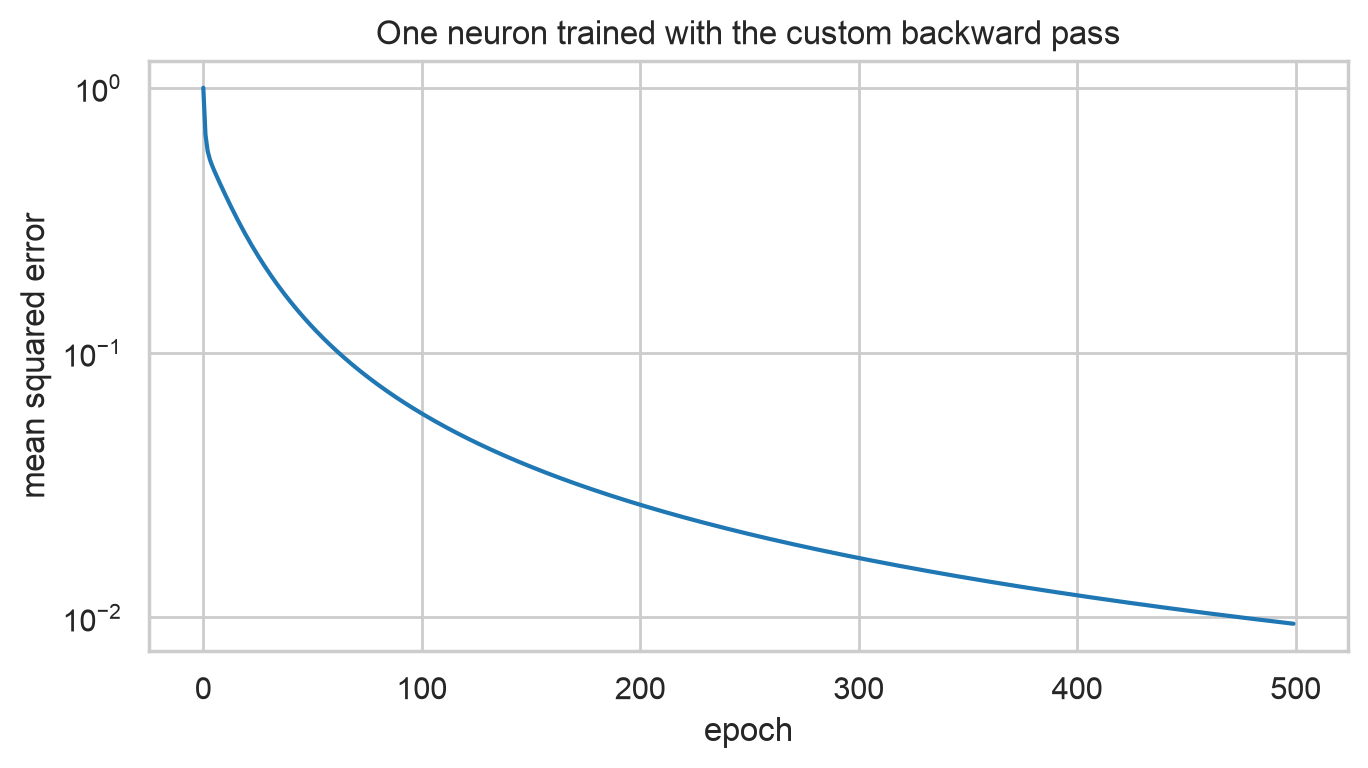

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

prediction_rows = []
w1, w2, bias = parameters
for features, target in data:
    score = (w1 * features[0] + w2 * features[1] + bias).tanh()
    prediction_rows.append({'x1': features[0], 'x2': features[1], 'target': target, 'prediction': score.data})
prediction_table = pd.DataFrame(prediction_rows)
print(prediction_table.round(3).to_string(index=False))

sns.set_theme(style='whitegrid', context='notebook')
fig, ax = plt.subplots(figsize=(7, 4))
sns.lineplot(x=range(len(loss_history)), y=loss_history, ax=ax, color='tab:blue')
ax.set(yscale='log', xlabel='epoch', ylabel='mean squared error', title='One neuron trained with the custom backward pass')
fig.tight_layout()
plt.show()


## Reference

[karpathy/micrograd](https://github.com/karpathy/micrograd)